# Exploratory Data Analysis (EDA) - Spectrograms

This notebook focuses on cleaning, analyzing, and normalizing the generated spectrogram data.

In [21]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import hashlib
from tqdm import tqdm

## 1. Data Loading and Initial Stats

In [22]:
base_dir = 'spectrograms'
classes = ['class_0', 'class_1']

data = []
for cls in classes:
    path = os.path.join(base_dir, cls, '*.png')
    files = [f for f in glob.glob(path) if '_aug_' not in os.path.basename(f)]
    for f in files:
        data.append({'path': f, 'label': cls, 'filename': os.path.basename(f)})

df = pd.DataFrame(data)
print(f"Total original (non-augmented) files found: {len(df)}")
print(df['label'].value_counts())

Total original (non-augmented) files found: 2090
label
class_0    2058
class_1      32
Name: count, dtype: int64


## 2. Data Cleaning: Duplicate Detection

We use hashing to find identical images that might have been generated multiple times.

In [23]:
def get_image_hash(fname):
    with open(fname, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

tqdm.pandas(desc="Hashing images")
df['hash'] = df['path'].progress_apply(get_image_hash)

duplicates = df[df.duplicated('hash', keep=False)]
print(f"Number of duplicate entries found: {len(df[df.duplicated('hash')])}")

df_clean = df.drop_duplicates('hash').copy()
print(f"Remaining files after cleaning: {len(df_clean)}")

Hashing images: 100%|██████████| 2090/2090 [00:00<00:00, 9424.27it/s]

Number of duplicate entries found: 0
Remaining files after cleaning: 2090


## 3. Data Normalization and Distribution

Check pixel value distributions.

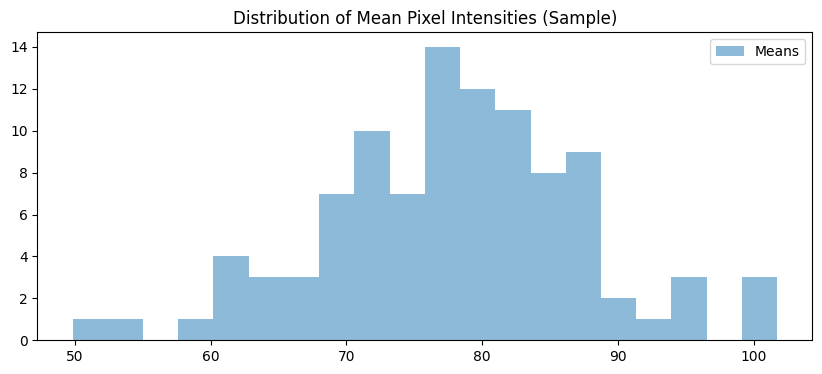

In [24]:
def get_image_stats(img_path):
    img = np.array(Image.open(img_path).convert('L'))
    return img.mean(), img.std(), img.min(), img.max()

sample_stats = [get_image_stats(p) for p in df_clean['path'].sample(min(100, len(df_clean)))]
means, stds, mins, maxs = zip(*sample_stats)

plt.figure(figsize=(10, 4))
plt.hist(means, bins=20, alpha=0.5, label='Means')
plt.title("Distribution of Mean Pixel Intensities (Sample)")
plt.legend()
plt.show()

## 4. Mean Spectrogram Analysis
Let's visualize the average spectrogram for Class 0 vs Class 1 to see macroscopic differences.

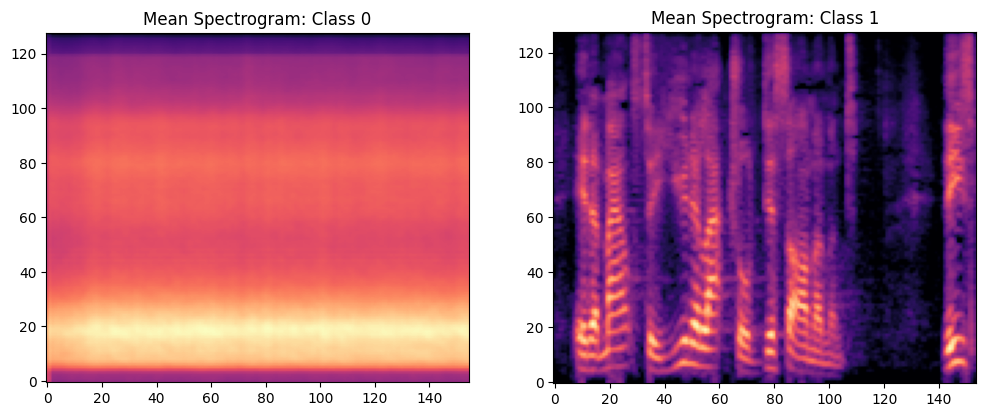

In [25]:
def compute_mean_spectrogram(cls_label):
    cls_data = df[df['label'] == cls_label]
    sum_img = None
    count = 0
    for path in cls_data['path']:
        try:
            img = np.array(Image.open(path).convert('L'), dtype=np.float32)
            if sum_img is None:
                sum_img = img
            else:
                if img.shape == sum_img.shape:
                    sum_img += img
            count += 1
        except:
            pass
    if count > 0:
        return sum_img / count
    return None

mean_class0 = compute_mean_spectrogram('class_0')
mean_class1 = compute_mean_spectrogram('class_1')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
if mean_class0 is not None:
    ax[0].imshow(mean_class0, cmap='magma', origin='lower')
    ax[0].set_title('Mean Spectrogram: Class 0')
if mean_class1 is not None:
    ax[1].imshow(mean_class1, cmap='magma', origin='lower')
    ax[1].set_title('Mean Spectrogram: Class 1')
plt.show()


## 5. Pixel Intensity Histograms
Comparing the distribution of pixel intensities between the two classes to identify if one class is generally louder or quieter.

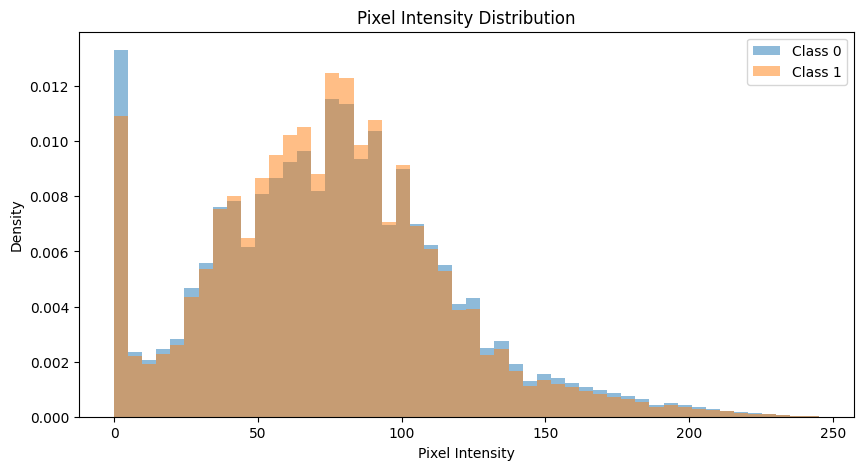

In [26]:
def get_intensity_histogram(cls_label):
    cls_data = df[df['label'] == cls_label]
    intensities = []
    # Sample up to 100 images for speed
    sample_paths = cls_data['path'].sample(n=min(100, len(cls_data)))
    for path in sample_paths:
        try:
            img = np.array(Image.open(path).convert('L'))
            intensities.extend(img.flatten())
        except:
            pass
    return intensities

hist0 = get_intensity_histogram('class_0')
hist1 = get_intensity_histogram('class_1')

plt.figure(figsize=(10, 5))
plt.hist(hist0, bins=50, alpha=0.5, label='Class 0', density=True)
plt.hist(hist1, bins=50, alpha=0.5, label='Class 1', density=True)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Density')
plt.legend()
plt.show()
